# Importing Modules

In [1]:
import pandas as pd
import matplotlib.pyplot as plt 
import yfinance as yf
import numpy as np

# Getting The Required Tickers

In [2]:
ticker = pd.read_csv('ind_nifty100list.csv') # Downloaded the Nifty 100 Index Contituent from nse website
ticker.head()

,Company Name,Industry,Symbol,Series,ISIN Code
0,ABB India Ltd.,Capital Goods,ABB,EQ,INE117A01022
1,Adani Energy Solutions Ltd.,Power,ADANIENSOL,EQ,INE931S01010
2,Adani Enterprises Ltd.,Metals & Mining,ADANIENT,EQ,INE423A01024
3,Adani Green Energy Ltd.,Power,ADANIGREEN,EQ,INE364U01010
4,Adani Ports and Special Economic Zone Ltd.,Services,ADANIPORTS,EQ,INE742F01042


In [3]:
ticker = ticker['Symbol'] # Just getting its tickers
ticker.shape # has 104  stocks ??

(104,)

In [4]:
pd.set_option('display.max_rows',104)
ticker.head(104) # Trying to find out the 4 odd stocks

0             ABB
1      ADANIENSOL
2        ADANIENT
3      ADANIGREEN
4      ADANIPORTS
5      ADANIPOWER
6       AMBUJACEM
7      APOLLOHOSP
8      ASIANPAINT
9           DMART
10       AXISBANK
11     BAJAJ-AUTO
12     BAJFINANCE
13     BAJAJFINSV
14     BAJAJHLDNG
15     BANKBARODA
16            BEL
17           BPCL
18     BHARTIARTL
19       BOSCHLTD
20      BRITANNIA
21        CGPOWER
22          CANBK
23       CHOLAFIN
24          CIPLA
25      COALINDIA
26     CUMMINSIND
27            DLF
28       DIVISLAB
29        DRREDDY
30     DUMMYVEDL1
31     DUMMYVEDL2
32     DUMMYVEDL3
33     DUMMYVEDL4
34      EICHERMOT
35        ETERNAL
36           GAIL
37       GODREJCP
38         GRASIM
39        HCLTECH
40        HDFCAMC
41       HDFCBANK
42       HDFCLIFE
43       HINDALCO
44            HAL
45     HINDUNILVR
46       HINDZINC
47        HYUNDAI
48      ICICIBANK
49            ITC
50       INDHOTEL
51            IOC
52           IRFC
53           INFY
54         INDIGO
55       J

In [5]:
filt = ticker.str.contains('DUMMY') # Stocks were named DUMMY 
ticker = ticker[~filt] #u Removing the odd stocks using the created filter

In [6]:
ticker.shape # making sure all the stocks are removed

(100,)

# Downloading The Dataset

In [7]:
ticker = list(x + '.NS' for x in ticker) # Converting the tickers to a list with .NS suffix
df = yf.download(tickers = list(ticker), period = '5y') # Downloading the data

[*********************100%***********************]  100 of 100 completed


In [8]:
df.head()

Price             Close                                           \
Ticker           ABB.NS ADANIENSOL.NS  ADANIENT.NS ADANIGREEN.NS   
2021-05-31  1631.910400   1473.599976  1313.110474   1268.199951   
2021-06-01  1655.770386   1499.449951  1412.818115   1271.050049   
2021-06-02  1662.908936   1558.250000  1543.002075   1299.800049   
2021-06-03  1654.499023   1577.900024  1579.264038   1286.900024   
2021-06-04  1613.966553   1602.050049  1696.828369   1277.250000   

Price                                                              \
Ticker     ADANIPORTS.NS ADANIPOWER.NS AMBUJACEM.NS APOLLOHOSP.NS   
2021-05-31    747.015564     18.500000   316.024414   3127.853027   
2021-06-01    774.826599     19.070000   313.510193   3197.986084   
2021-06-02    787.737183     19.280001   320.182678   3231.350098   
2021-06-03    801.133118     20.150000   322.938690   3381.437500   
2021-06-04    809.432678     21.150000   321.101288   3336.524902   

Price                                 ...        Volume             \
Ticker     ASIANPAINT.NS AXISBANK.NS  ... TORNTPHARM.NS   TRENT.NS   
2021-05-31   2849.976807  747.578613  ...      207192.0  1296401.0   
2021-06-01   2805.468750  742.051697  ...      765228.0   697195.0   
2021-06-02   2779.338135  733.935547  ...      553158.0   826415.0   
2021-06-03   2809.632324  747.528870  ...      284992.0   404997.0   
2021-06-04   2799.629883  738.964539  ...      319268.0   781342.0   

Price                                                                   \
Ticker     TVSMOTOR.NS ULTRACEMCO.NS UNIONBANK.NS UNITDSPR.NS   VBL.NS   
2021-05-31     2432413      328449.0     21104866         NaN  1735807   
2021-06-01     2654612      397989.0     13024994         NaN  1502493   
2021-06-02     1687313      567704.0     26505584         NaN  3667106   
2021-06-03     2252658      349479.0     20258579         NaN  1127317   
2021-06-04     2035626      205504.0     19102745         NaN  6768461   

Price                                        
Ticker       VEDL.NS  WIPRO.NS ZYDUSLIFE.NS  
2021-05-31  11125660  10772410    4405464.0  
2021-06-01  11911215  11930088    3540399.0  
2021-06-02   9303223   9427136    5561507.0  
2021-06-03  11241144  11275982    4524635.0  
2021-06-04  12113422   9543432    5495252.0  

[5 rows x 500 columns]

In [9]:
df.shape

(1238, 500)

In [10]:
df = df['Close'] # Just wanna work with the closing values of stocks

In [11]:
df.info()

<class 'pandas.DataFrame'>
DatetimeIndex: 1238 entries, 2021-05-31 to 2026-05-29
Data columns (total 100 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   ABB.NS         1238 non-null   float64
 1   ADANIENSOL.NS  1238 non-null   float64
 2   ADANIENT.NS    1238 non-null   float64
 3   ADANIGREEN.NS  1238 non-null   float64
 4   ADANIPORTS.NS  1237 non-null   float64
 5   ADANIPOWER.NS  1238 non-null   float64
 6   AMBUJACEM.NS   1238 non-null   float64
 7   APOLLOHOSP.NS  1238 non-null   float64
 8   ASIANPAINT.NS  1238 non-null   float64
 9   AXISBANK.NS    1237 non-null   float64
 10  BAJAJ-AUTO.NS  1238 non-null   float64
 11  BAJAJFINSV.NS  1238 non-null   float64
 12  BAJAJHLDNG.NS  1238 non-null   float64
 13  BAJFINANCE.NS  1238 non-null   float64
 14  BANKBARODA.NS  1238 non-null   float64
 15  BEL.NS         1238 non-null   float64
 16  BHARTIARTL.NS  1238 non-null   float64
 17  BOSCHLTD.NS    1236 non-null   float64
 18  

# Trying To Findout Stocks Having More Than 5% Null Values And Cleaning The Dataset

In [12]:
filt = (df.isna().sum(axis = 'rows')/df.shape[0] * 100 > 5) # Creating a filter to check how many stockas have a null values which constitute more than 5% 
filt.sum() # Finding out the number of stocks 

np.int64(8)

In [13]:
df.drop(columns = df.columns[filt], inplace = True) # Removing the stocks with too muhc null values

In [14]:
df.shape

(1238, 92)

In [15]:
df.ffill(inplace = True)
df.head()

Ticker,ABB.NS,ADANIENSOL.NS,ADANIENT.NS,ADANIGREEN.NS,ADANIPORTS.NS,ADANIPOWER.NS,AMBUJACEM.NS,APOLLOHOSP.NS,ASIANPAINT.NS,AXISBANK.NS,...,TITAN.NS,TORNTPHARM.NS,TRENT.NS,TVSMOTOR.NS,ULTRACEMCO.NS,UNIONBANK.NS,VBL.NS,VEDL.NS,WIPRO.NS,ZYDUSLIFE.NS
2021-05-31,1631.910400,1473.599976,1313.110474,1268.199951,747.015564,18.500000,316.024414,3127.853027,2849.976807,747.578613,...,1571.802734,1286.816040,847.136475,601.408875,6526.803223,29.968723,88.602142,131.464966,249.013916,596.339539
2021-06-01,1655.770386,1499.449951,1412.818115,1271.050049,774.826599,19.070000,313.510193,3197.986084,2805.468750,742.051697,...,1567.026978,1307.610596,835.747192,598.964905,6423.034180,29.666443,88.177322,128.612259,250.746231,597.448792
2021-06-02,1662.908936,1558.250000,1543.002075,1299.800049,787.737183,19.280001,320.182678,3231.350098,2779.338135,733.935547,...,1561.414429,1311.999634,848.628540,602.826355,6416.077148,30.443729,89.245926,131.944427,250.838608,605.116394
2021-06-03,1654.499023,1577.900024,1579.264038,1286.900024,801.133118,20.150000,322.938690,3381.437500,2809.632324,747.528870,...,1665.298584,1302.705200,850.220032,610.891479,6462.294434,30.573282,90.038620,133.023163,249.013916,611.867737
2021-06-04,1613.966553,1602.050049,1696.828369,1277.250000,809.432678,21.150000,321.101288,3336.524902,2799.629883,738.964539,...,1653.777710,1319.768311,847.584106,609.424988,6484.283691,30.616463,92.688225,134.653305,250.007126,613.893127


# Starting The necessary Computations

In [16]:
df = df.pct_change() * 100 # Using pct_change in stock price to make correlation
df.head()

Ticker,ABB.NS,ADANIENSOL.NS,ADANIENT.NS,ADANIGREEN.NS,ADANIPORTS.NS,ADANIPOWER.NS,AMBUJACEM.NS,APOLLOHOSP.NS,ASIANPAINT.NS,AXISBANK.NS,...,TITAN.NS,TORNTPHARM.NS,TRENT.NS,TVSMOTOR.NS,ULTRACEMCO.NS,UNIONBANK.NS,VBL.NS,VEDL.NS,WIPRO.NS,ZYDUSLIFE.NS
2021-05-31,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2021-06-01,1.462089,1.754206,7.593241,0.224736,3.722953,3.081079,-0.795578,2.242211,-1.561699,-0.739309,...,-0.303839,1.615970,-1.344445,-0.406374,-1.589891,-1.008653,-0.479469,-2.169937,0.695670,0.186010
2021-06-02,0.431132,3.921441,9.214488,2.261909,1.666255,1.101211,2.128315,1.043282,-0.931417,-1.093745,...,-0.358165,0.335653,1.541297,0.644687,-0.108314,2.620087,1.211880,2.590864,0.036841,1.283391
2021-06-03,-0.505735,1.261032,2.350092,-0.992462,1.700559,4.512442,0.860762,4.644727,1.089979,1.852114,...,6.653208,-0.708417,0.187537,1.337885,0.720336,0.425549,0.888213,0.817568,-0.727437,1.115710
2021-06-04,-2.449833,1.530517,7.444248,-0.749866,1.035978,4.962779,-0.568963,-1.328210,-0.356005,-1.145686,...,-0.691820,1.309821,-0.310029,-0.240058,0.340270,0.141236,2.942743,1.225457,0.398857,0.331018


In [17]:
df.dropna(inplace = True) # Removing null values

In [18]:
df.shape

(1199, 92)

In [19]:
data = df.copy()

In [20]:
df = df.rolling(30).std() # Getting their volitility for 30 day windows
df.dropna(inplace = True)
df

Ticker,ABB.NS,ADANIENSOL.NS,ADANIENT.NS,ADANIGREEN.NS,ADANIPORTS.NS,ADANIPOWER.NS,AMBUJACEM.NS,APOLLOHOSP.NS,ASIANPAINT.NS,AXISBANK.NS,...,TITAN.NS,TORNTPHARM.NS,TRENT.NS,TVSMOTOR.NS,ULTRACEMCO.NS,UNIONBANK.NS,VBL.NS,VEDL.NS,WIPRO.NS,ZYDUSLIFE.NS
2021-09-06,2.011807,2.974215,2.106716,2.162457,1.804103,3.782809,1.524857,3.127569,1.360954,1.465804,...,1.512219,1.460931,1.903761,1.515900,1.459965,1.912534,1.869508,3.589320,1.307767,1.737586
2021-09-07,2.012076,2.939359,2.135856,2.007865,1.815312,3.866333,1.511923,3.097554,1.349684,1.503116,...,1.506511,1.463601,1.922298,1.538082,1.440171,1.907783,1.884145,3.596090,1.325414,1.721546
2021-09-08,1.939616,2.701510,2.131659,2.009345,1.713648,3.926531,1.537534,3.111493,1.326433,1.363534,...,1.508901,1.385001,1.950932,1.549613,1.442073,1.908812,1.854467,3.559575,1.386515,1.716341
2021-09-09,1.926857,2.696879,2.140743,2.097606,1.713593,4.001043,1.538583,3.127836,1.308849,1.344555,...,1.529969,1.294987,1.966633,1.543661,1.446213,1.896390,1.833099,3.554199,1.387026,1.637281
2021-09-13,1.922044,2.663875,2.150576,2.112050,1.707756,4.005528,1.542549,3.127260,1.304774,1.332865,...,1.534469,1.263778,1.978278,1.486117,1.443772,1.421628,1.829258,3.371015,1.390713,1.631337
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2026-05-25,2.406308,2.621668,2.320579,2.257912,1.762824,2.597611,1.607065,1.161660,1.560030,1.338303,...,1.888808,1.397603,1.912188,1.865357,1.281155,2.131723,2.086116,12.349607,1.510424,1.888069
2026-05-26,2.408432,2.696181,2.384458,2.291998,1.744621,2.660677,1.628456,1.223208,1.560981,1.345211,...,1.885173,1.497052,1.922096,1.812980,1.284105,2.101630,2.081664,12.377357,1.526656,1.887631
2026-05-27,2.650135,2.807526,2.390532,2.302722,1.682236,2.664208,1.589872,1.196567,1.486127,1.347432,...,1.853380,1.521717,1.870826,1.819909,1.205311,2.058052,2.016073,12.387653,1.403318,1.879411
2026-05-28,2.650400,2.735647,2.378265,2.302006,1.648070,2.544983,1.581983,1.166893,1.485635,1.346263,...,1.842947,1.521079,1.815035,1.819882,1.203320,2.058622,1.952896,12.373436,1.401833,1.881469


In [21]:
corr_mat = df.corr() # Getting the correlation stock

In [22]:
corr_mat = corr_mat.unstack() # Trying to get a combination of pairs of stocks

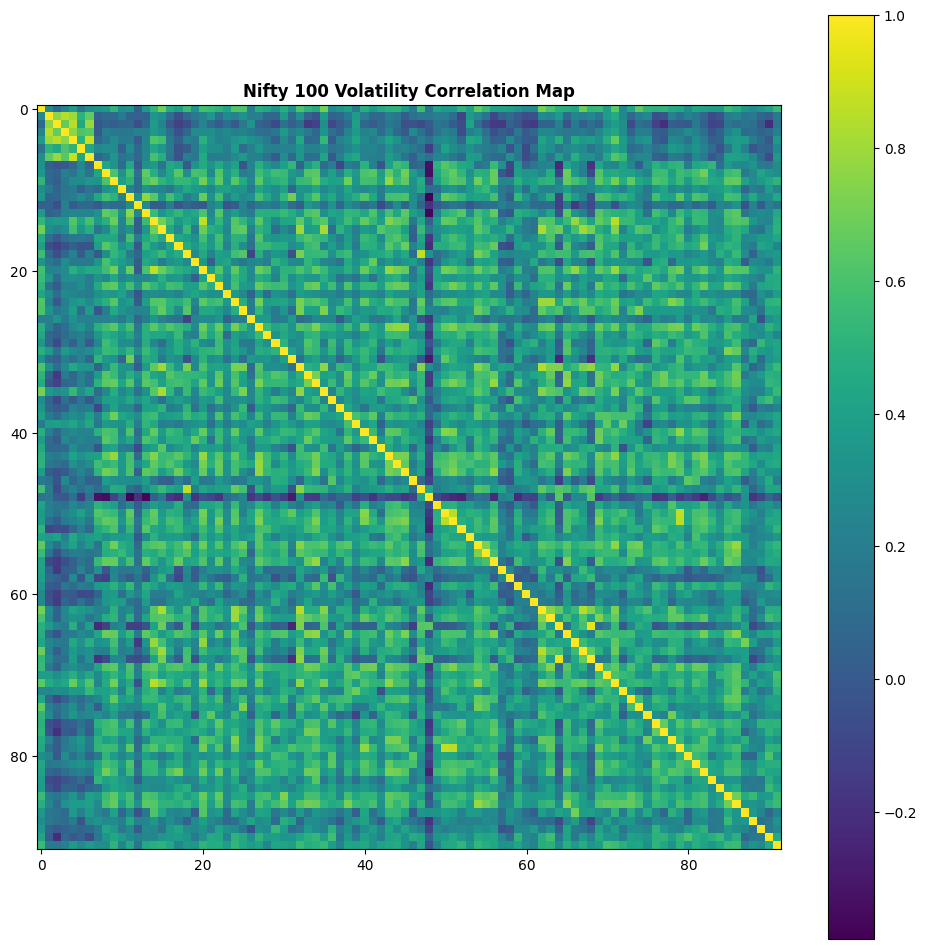

In [23]:
plt.figure(figsize = (12,12))
plt.imshow(df.corr())
plt.title('Nifty 100 Volatility Correlation Map', fontweight = 'bold')
plt.colorbar()
plt.show()

In [24]:
corr_mat = corr_mat[corr_mat.index.get_level_values(0) != corr_mat.index.get_level_values(1)] # Removing same pairing of stocks
corr_mat

Ticker        Ticker       
ABB.NS        ADANIENSOL.NS    0.264412
              ADANIENT.NS      0.088099
              ADANIGREEN.NS    0.235608
              ADANIPORTS.NS    0.374130
              ADANIPOWER.NS    0.141847
                                 ...   
ZYDUSLIFE.NS  ULTRACEMCO.NS    0.557933
              UNIONBANK.NS     0.235300
              VBL.NS           0.327563
              VEDL.NS          0.262736
              WIPRO.NS         0.461496
Length: 8372, dtype: float64

# Top 10 Stocks with high correlation in Nifty 100 with Examples

In [25]:
corr_mat.nlargest(20)[::2] # getting the 10 largest stock

Ticker         Ticker       
PFC.NS         RECLTD.NS        0.955942
ADANIPORTS.NS  AMBUJACEM.NS     0.883762
JINDALSTEL.NS  TATASTEEL.NS     0.868329
BPCL.NS        IOC.NS           0.868047
BANKBARODA.NS  CANBK.NS         0.867313
ADANIENT.NS    ADANIPORTS.NS    0.856255
JSWSTEEL.NS    TATASTEEL.NS     0.855443
BANKBARODA.NS  SBIN.NS          0.849374
JINDALSTEL.NS  JSWSTEEL.NS      0.849308
ADANIENSOL.NS  ADANIGREEN.NS    0.847454
dtype: float64

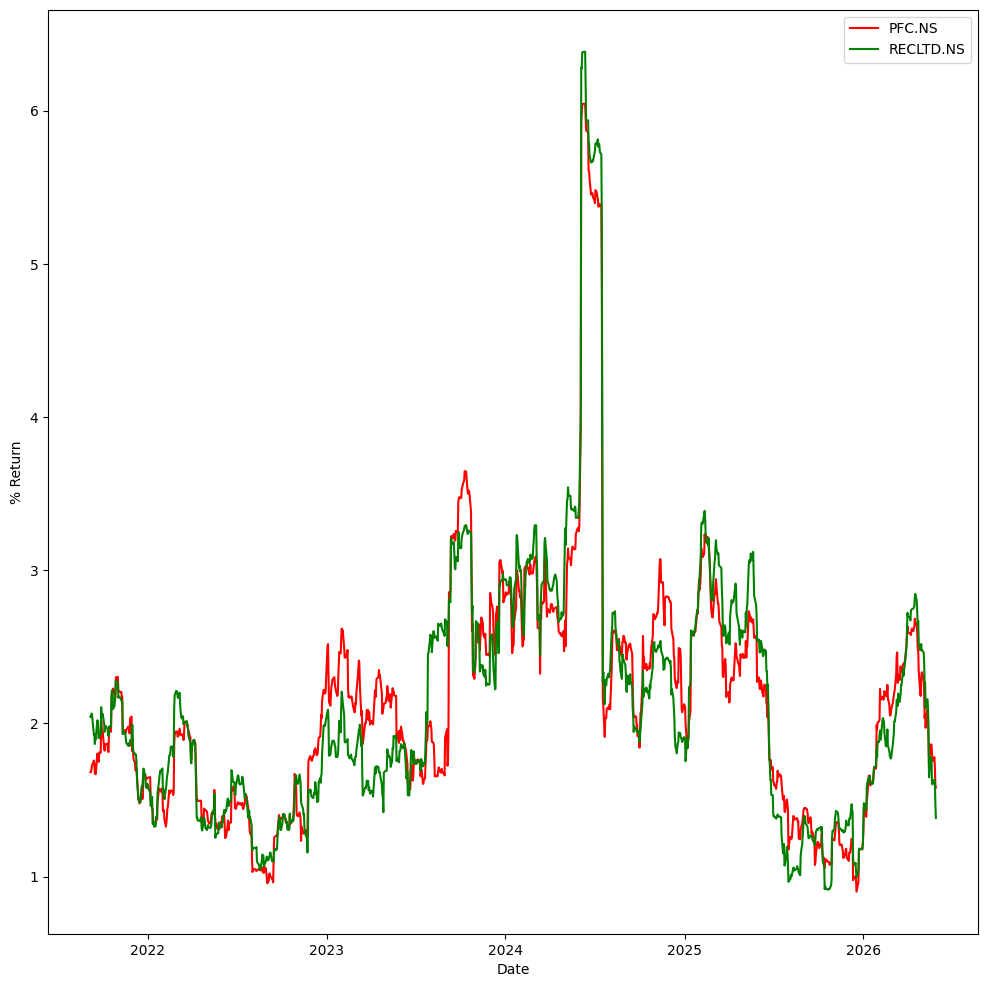

In [26]:
plt.figure(figsize = (12,12))
plt.plot(df['PFC.NS'], color = 'red')
plt.plot(df['RECLTD.NS'], color = 'green')
plt.legend(['PFC.NS','RECLTD.NS'])
plt.xlabel('Date')
plt.ylabel('% Return')
plt.show()

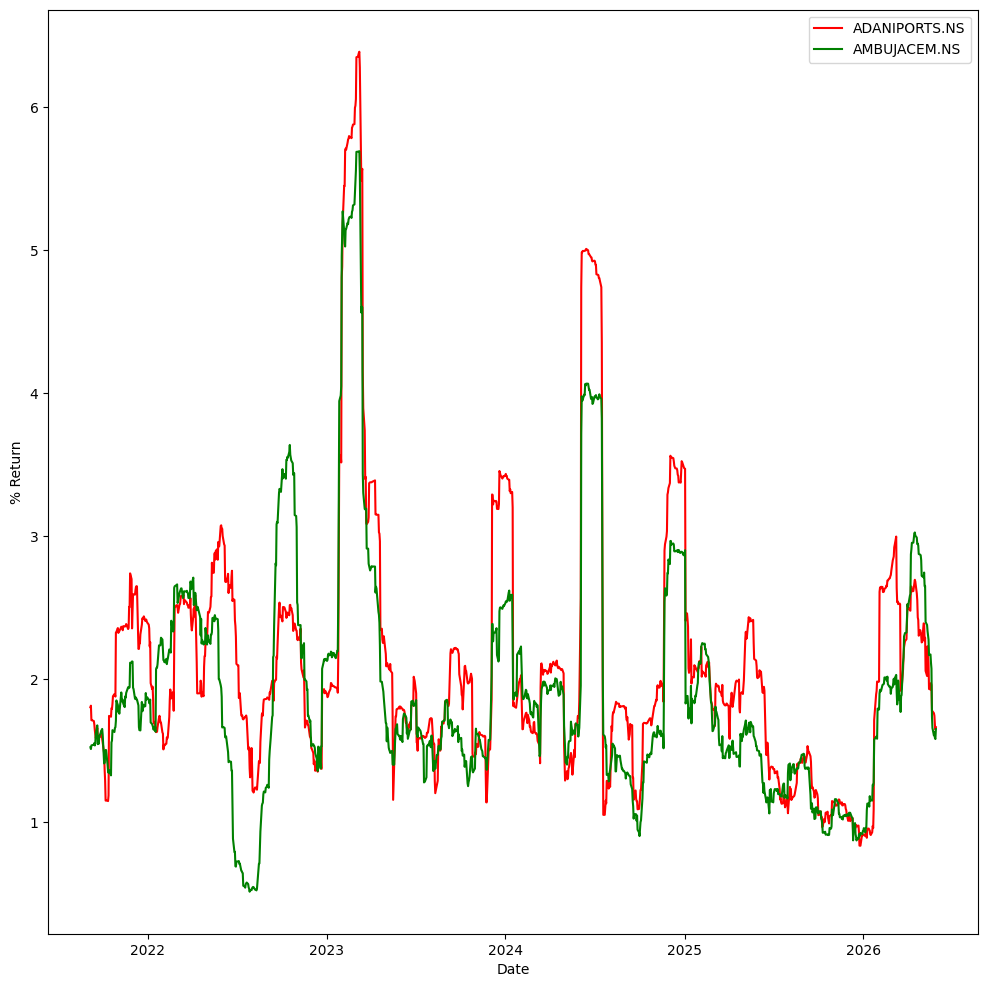

In [27]:
plt.figure(figsize = (12,12))
plt.plot(df['ADANIPORTS.NS'], color = 'red')
plt.plot(df['AMBUJACEM.NS'], color = 'green')
plt.legend(['ADANIPORTS.NS','AMBUJACEM.NS'])
plt.xlabel('Date')
plt.ylabel('% Return')
plt.show()

# Comparing The Performance Difference Between Pandas and Numpy in Calculating Volitility

In [28]:
data_p = data.copy()
data_n = data.copy()

In [43]:
import timeit

pandas_time = timeit.timeit(
    stmt='data_p.rolling(30).std()', 
    globals=globals(), 
    number=100
)
print(f"Pandas rolling (average over 100 loops): {pandas_time / 100:.6f} seconds")

def std_calc(data):
    ind = np.arange(30) + np.arange(data.shape[0] - 30)[:,np.newaxis]
    val = data.values[ind]
    mean = val.mean(axis = 1, keepdims = True)
    return np.sqrt(((val - mean)**2).mean(axis = 1))

numpy_time = timeit.timeit(
    stmt='std_calc(data_n)', 
    globals=globals(), 
    number=100
)
print(f"NumPy rolling (average over 100 loops): {numpy_time / 100:.6f} seconds")

Pandas rolling (average over 100 loops): 0.005312 seconds
NumPy rolling (average over 100 loops): 0.012792 seconds


### Standard use of pandas was faster than broadcasting in numpy